<a href="https://colab.research.google.com/github/heenameheraj-ux/Revuora/blob/main/Review_Summarizer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
"""
clean.py - Task 2: clean the raw scraped reviews.

Main function:
    clean_reviews(df) -> (clean_df, counts)   counts = {"scraped", "removed", "kept"}

Run:  python clean.py
Reads every CSV in data/raw/ and saves the cleaned version to data/cleaned/<product>.csv
"""
import glob
import os
import re
from urllib.parse import urlparse

import pandas as pd

RAW_DIR = "data/raw"
CLEAN_DIR = "data/cleaned"
MIN_WORDS = 3

# Names that the scraper sometimes picks up by mistake from the search card
BAD_NAMES = {"currently unavailable", "sponsored", "ad", "assured", "add to compare", ""}

# Flipkart's truncated preview ends with "... more" or "Read more"
TRAILING_MORE = re.compile(r"\s*(?:\.{2,}|\u2026)\s*(?:read\s+)?more\s*$|\s+read more\s*$", re.I)


def name_from_url(url):
    """.../redmi-note-13-pro-5g-midnight-black-256-gb/p/... -> 'Redmi Note 13 Pro 5G Midnight Black 256 GB'"""
    try:
        slug = urlparse(str(url)).path.strip("/").split("/")[0]
    except Exception:
        return ""
    words = [w for w in slug.split("-") if w]
    out = []
    for w in words:
        if w.lower() in {"5g", "4g", "gb", "tb", "ram", "rom"}:
            out.append(w.upper() if w.lower() in {"5g", "4g", "gb", "tb"} else w.upper())
        else:
            out.append(w.capitalize())
    return " ".join(out)


def fix_product_name(df):
    """Replace 'Currently unavailable' style names using the product URL."""
    if "product_name" not in df.columns:
        return df
    bad = df["product_name"].astype(str).str.strip().str.lower().isin(BAD_NAMES) | df["product_name"].isna()
    if bad.any() and "product_url" in df.columns:
        df.loc[bad, "product_name"] = df.loc[bad, "product_url"].apply(name_from_url)
    return df


def _tidy_text(s):
    """Collapse spaces/line breaks, drop the trailing '... more'."""
    if pd.isna(s):
        return pd.NA
    s = re.sub(r"\s+", " ", str(s)).strip()
    s = TRAILING_MORE.sub("", s).strip()
    return s if s else pd.NA


def clean_reviews(df):
    df = df.copy()
    scraped = len(df)

    # 1. product name fix (no rows removed)
    df = fix_product_name(df)

    # 2. strip spaces and line breaks, empty -> missing
    for col in ("title", "text"):
        df[col] = df[col].apply(_tidy_text)

    # 3. drop empty text, then duplicates (same title and text)
    df = df.dropna(subset=["text"])
    df = df.drop_duplicates(subset=["title", "text"])

    # 4. drop reviews with fewer than 3 words
    df = df[df["text"].str.split().str.len() >= MIN_WORDS]

    # 5. rating to number, keep 1 to 5
    df["rating"] = pd.to_numeric(df["rating"], errors="coerce")
    df = df[df["rating"].between(1, 5)]
    df["rating"] = df["rating"].astype(int)

    # 6. date: Flipkart gives month and year only (e.g. "Nov, 2024")
    df["date"] = pd.to_datetime(df["date"], format="%b, %Y", errors="coerce")

    # 7. helpful votes to number, missing -> 0
    df["helpful_votes"] = pd.to_numeric(df["helpful_votes"], errors="coerce").fillna(0).astype(int)

    df["title"] = df["title"].fillna("")
    df = df.reset_index(drop=True)

    kept = len(df)
    counts = {"scraped": scraped, "removed": scraped - kept, "kept": kept}
    return df, counts


def clean_file(raw_path):
    """Clean one raw CSV and save data/cleaned/<same file name>."""
    os.makedirs(CLEAN_DIR, exist_ok=True)
    df = pd.read_csv(raw_path)
    clean_df, counts = clean_reviews(df)
    out = os.path.join(CLEAN_DIR, os.path.basename(raw_path))
    clean_df.to_csv(out, index=False, encoding="utf-8-sig")
    return clean_df, counts, out


if __name__ == "__main__":
    files = sorted(glob.glob(os.path.join(RAW_DIR, "*.csv")))
    if not files:
        print(f"No CSV files found in {RAW_DIR}. Run scraper.py first.")
        raise SystemExit

    table = []
    for f in files:
        clean_df, c, out = clean_file(f)
        name = clean_df["product_name"].iloc[0] if len(clean_df) else os.path.basename(f)
        print(f"\n{name}")
        print(f"  Scraped {c['scraped']}, removed {c['removed']}, kept {c['kept']}  ->  {out}")
        print(f"  Missing rating: {clean_df['rating'].isna().sum()} | Missing text: {clean_df['text'].isna().sum()}"
              f" | Missing date: {clean_df['date'].isna().sum()}")
        table.append({"product": name, **c})

    summary = pd.DataFrame(table)
    print("\nCleaning counts (put this table in your report):")
    print(summary.to_string(index=False))
    summary.to_csv(os.path.join(CLEAN_DIR, "_cleaning_counts.csv"), index=False)

    # show one sample so you can check the '... more' fix worked
    sample = clean_df.head(3)[["rating", "title", "text", "date", "helpful_votes"]]
    print("\nSample rows:")
    print(sample.to_string())

No CSV files found in data/raw. Run scraper.py first.


SystemExit: 

/usr/local/lib/python3.13/dist-packages/IPython/core/interactiveshell.py:3561: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [2]:
import os, shutil, glob
os.makedirs("data/raw", exist_ok=True)
for f in glob.glob("*.csv"):
    shutil.move(f, "data/raw/")
print(os.listdir("data/raw"))

['oppo_reno_12_5g.csv', 'poco_x6_pro_5g.csv', 'samsung_galaxy_m35_5g.csv', 'redmi_note_13_pro_5g.csv', 'realme_narzo_70_pro_5g.csv']


In [9]:
"""
clean.py - Task 2: clean the raw scraped reviews.

Main function:
    clean_reviews(df) -> (clean_df, counts)   counts = {"scraped", "removed", "kept"}

Run:  python clean.py
Reads every CSV in data/raw/ and saves the cleaned version to data/cleaned/<product>.csv
"""
import glob
import os
import re
from urllib.parse import urlparse

import pandas as pd

RAW_DIR = "data/raw"
CLEAN_DIR = "data/cleaned"
MIN_WORDS = 3

# Names that the scraper sometimes picks up by mistake from the search card
BAD_NAMES = {"currently unavailable", "sponsored", "ad", "assured", "add to compare", ""}

# Flipkart's truncated preview ends with "... more" or "Read more"
TRAILING_MORE = re.compile(r"\s*(?:\.{2,}|\u2026)\s*(?:read\s+)?more\s*$|\s+read more\s*$", re.I)


def name_from_url(url):
    """.../redmi-note-13-pro-5g-midnight-black-256-gb/p/... -> 'Redmi Note 13 Pro 5G Midnight Black 256 GB'"""
    try:
        slug = urlparse(str(url)).path.strip("/").split("/")[0]
    except Exception:
        return ""
    words = [w for w in slug.split("-") if w]
    out = []
    for w in words:
        if w.lower() in {"5g", "4g", "gb", "tb", "ram", "rom"}:
            out.append(w.upper() if w.lower() in {"5g", "4g", "gb", "tb"} else w.upper())
        else:
            out.append(w.capitalize())
    return " ".join(out)


def fix_product_name(df):
    """Replace 'Currently unavailable' style names using the product URL."""
    if "product_name" not in df.columns:
        return df
    bad = df["product_name"].astype(str).str.strip().str.lower().isin(BAD_NAMES) | df["product_name"].isna()
    if bad.any() and "product_url" in df.columns:
        df.loc[bad, "product_name"] = df.loc[bad, "product_url"].apply(name_from_url)
    return df


def _tidy_text(s):
    """Collapse spaces/line breaks, drop the trailing '... more'."""
    if pd.isna(s):
        return pd.NA
    s = re.sub(r"\s+", " ", str(s)).strip()
    s = TRAILING_MORE.sub("", s).strip()
    return s if s else pd.NA


def clean_reviews(df):
    df = df.copy()
    scraped = len(df)

    # 1. product name fix (no rows removed)
    df = fix_product_name(df)

    # 2. strip spaces and line breaks, empty -> missing
    for col in ("title", "text"):
        df[col] = df[col].apply(_tidy_text)

    # 3. drop empty text, then duplicates (same title and text)
    df = df.dropna(subset=["text"])
    df = df.drop_duplicates(subset=["title", "text"])

    # 4. drop reviews with fewer than 3 words
    df = df[df["text"].str.split().str.len() >= MIN_WORDS]

    # 5. rating to number, keep 1 to 5
    df["rating"] = pd.to_numeric(df["rating"], errors="coerce")
    df = df[df["rating"].between(1, 5)]
    df["rating"] = df["rating"].astype(int)

    # 6. date: Flipkart gives month and year only (e.g. "Nov, 2024")
    df["date"] = pd.to_datetime(df["date"], format="%b, %Y", errors="coerce")

    # 7. helpful votes to number, missing -> 0
    df["helpful_votes"] = pd.to_numeric(df["helpful_votes"], errors="coerce").fillna(0).astype(int)

    df["title"] = df["title"].fillna("")
    df = df.reset_index(drop=True)

    kept = len(df)
    counts = {"scraped": scraped, "removed": scraped - kept, "kept": kept}
    return df, counts


def clean_file(raw_path):
    """Clean one raw CSV and save data/cleaned/<same file name>."""
    os.makedirs(CLEAN_DIR, exist_ok=True)
    df = pd.read_csv(raw_path)
    clean_df, counts = clean_reviews(df)
    out = os.path.join(CLEAN_DIR, os.path.basename(raw_path))
    clean_df.to_csv(out, index=False, encoding="utf-8-sig")
    return clean_df, counts, out


if __name__ == "__main__":
    files = sorted(glob.glob(os.path.join(RAW_DIR, "*.csv")))
    if not files:
        print(f"No CSV files found in {RAW_DIR}. Run scraper.py first.")
        raise SystemExit

    table = []
    for f in files:
        clean_df, c, out = clean_file(f)
        name = clean_df["product_name"].iloc[0] if len(clean_df) else os.path.basename(f)
        print(f"\n{name}")
        print(f"  Scraped {c['scraped']}, removed {c['removed']}, kept {c['kept']}  ->  {out}")
        print(f"  Missing rating: {clean_df['rating'].isna().sum()} | Missing text: {clean_df['text'].isna().sum()}"
              f" | Missing date: {clean_df['date'].isna().sum()}")
        table.append({"product": name, **c})

    summary = pd.DataFrame(table)
    print("\nCleaning counts (put this table in your report):")
    print(summary.to_string(index=False))
    summary.to_csv(os.path.join(CLEAN_DIR, "_cleaning_counts.csv"), index=False)

    # show one sample so you can check the '... more' fix worked
    sample = clean_df.head(3)[["rating", "title", "text", "date", "helpful_votes"]]
    print("\nSample rows:")
    print(sample.to_string())


OPPO Reno 12 5G (Matte Brown, 256 GB)
  Scraped 500, removed 196, kept 304  ->  data/cleaned/oppo_reno_12_5g.csv
  Missing rating: 0 | Missing text: 0 | Missing date: 25

POCO M7 Pro 5G (Lavender Frost, 128 GB)
  Scraped 399, removed 60, kept 339  ->  data/cleaned/poco_m6_pro_5g.csv
  Missing rating: 0 | Missing text: 0 | Missing date: 77

POCO X7 Pro 5G (Obsidian Black, 256 GB)
  Scraped 500, removed 56, kept 444  ->  data/cleaned/poco_x6_pro_5g.csv
  Missing rating: 0 | Missing text: 0 | Missing date: 117

Redmi Note 13 Pro 5G Fusion White 256 GB
  Scraped 500, removed 159, kept 341  ->  data/cleaned/redmi_note_13_pro_5g.csv
  Missing rating: 0 | Missing text: 0 | Missing date: 14

Samsung Galaxy M35 5G (Moonlight Blue, 128 GB)
  Scraped 500, removed 79, kept 421  ->  data/cleaned/samsung_galaxy_m35_5g.csv
  Missing rating: 0 | Missing text: 0 | Missing date: 82

Cleaning counts (put this table in your report):
                                       product  scraped  removed  kept
 

In [4]:
 !pip install -q wordcloud anthropic
import nltk
for x in ['punkt','punkt_tab','stopwords','wordnet','vader_lexicon']:
    nltk.download(x)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 11.1 MB/s eta 0:00:00


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


In [13]:
"""
preprocess.py - Task 3: text preprocessing, tokenization, lemmatization.

Main function:
    preprocess_reviews(df) -> df plus columns: clean_text, tokens, lemmas, review_len

Stages for one review:
    raw text -> clean_text -> tokens (stopwords removed) -> lemmas

Run:  python preprocess.py
Reads data/cleaned/*.csv, prints one review at every stage, saves data/processed/<product>.csv
"""
import glob
import os
import re

import nltk
import pandas as pd
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

CLEAN_DIR = "data/cleaned"
PROC_DIR = "data/processed"


def ensure_nltk():
    """Download NLTK data only if it is missing."""
    needed = {
        "tokenizers/punkt": "punkt",
        "tokenizers/punkt_tab": "punkt_tab",
        "corpora/stopwords": "stopwords",
        "corpora/wordnet": "wordnet",
    }
    for path, name in needed.items():
        try:
            nltk.data.find(path)
        except LookupError:
            nltk.download(name, quiet=True)


ensure_nltk()

# Negation words change the meaning ("not good"), so they are NOT removed.
KEEP_WORDS = {"not", "no", "never", "nor", "but"}
STOPWORDS = set(stopwords.words("english")) - KEEP_WORDS
LEMMATIZER = WordNetLemmatizer()

# Small contraction dictionary (special cases first, then the general n't rule)
CONTRACTIONS = {
    "can't": "cannot",
    "won't": "will not",
    "shan't": "shall not",
    "ain't": "is not",
    "i'm": "i am",
    "it's": "it is",
    "that's": "that is",
    "there's": "there is",
    "i've": "i have",
    "i'd": "i would",
    "i'll": "i will",
    "you're": "you are",
    "they're": "they are",
    "we're": "we are",
}

URL_RE = re.compile(r"(https?://\S+|www\.\S+)")
NON_ALNUM_RE = re.compile(r"[^a-z0-9\s]")
SPACES_RE = re.compile(r"\s+")


def expand_contractions(text):
    text = text.replace("\u2019", "'").replace("\u2018", "'")   # curly quotes -> '
    for short, full in CONTRACTIONS.items():
        text = re.sub(rf"\b{re.escape(short)}\b", full, text)
    text = re.sub(r"n't\b", " not", text)                        # general rule: don't -> do not
    return text


def make_clean_text(raw):
    """lowercase -> remove URLs -> expand contractions -> remove emojis/special characters."""
    t = str(raw).lower()
    t = URL_RE.sub(" ", t)
    t = expand_contractions(t)          # must run before apostrophes are removed
    t = NON_ALNUM_RE.sub(" ", t)        # keeps letters, numbers, spaces
    return SPACES_RE.sub(" ", t).strip()


def make_tokens(clean_text):
    """Tokenize with NLTK, then remove stopwords (negations are kept)."""
    return [w for w in word_tokenize(clean_text) if w not in STOPWORDS]


def lemmatize(word):
    """charging / charged -> charge, batteries -> battery (verb form first, then noun)."""
    return LEMMATIZER.lemmatize(LEMMATIZER.lemmatize(word, pos="v"), pos="n")


def make_lemmas(tokens):
    lemmas = [lemmatize(w) for w in tokens]
    return [w for w in lemmas if len(w) > 1 and not w.isdigit()]


def preprocess_reviews(df):
    df = df.copy()
    df["clean_text"] = df["text"].apply(make_clean_text)
    df["tokens"] = df["clean_text"].apply(make_tokens)
    df["lemmas"] = df["tokens"].apply(make_lemmas)
    df["review_len"] = df["text"].astype(str).str.split().str.len()
    return df


def show_stages(df, i=0):
    """Print one review at every stage (use this in the demo)."""
    row = df.iloc[i]
    print(f"\n--- Review #{i} ---")
    print("RAW        :", row["text"])
    print("CLEAN_TEXT :", row["clean_text"])
    print("TOKENS     :", row["tokens"])
    print("LEMMAS     :", row["lemmas"])


if __name__ == "__main__":
    files = [f for f in sorted(glob.glob(os.path.join(CLEAN_DIR, "*.csv")))
             if not os.path.basename(f).startswith("_")]
    if not files:
        print(f"No CSV files in {CLEAN_DIR}. Run clean.py first.")
        raise SystemExit

    os.makedirs(PROC_DIR, exist_ok=True)
    for f in files:
        df = pd.read_csv(f, parse_dates=["date"])
        out = preprocess_reviews(df)

        # save with tokens/lemmas as space-separated words so the CSV is readable
        save = out.copy()
        save["tokens"] = save["tokens"].apply(" ".join)
        save["lemmas"] = save["lemmas"].apply(" ".join)
        path = os.path.join(PROC_DIR, os.path.basename(f))
        save.to_csv(path, index=False, encoding="utf-8-sig")

        print(f"\n{os.path.basename(f)}: {len(out)} reviews processed -> {path}")
        print(f"  Average words per review: {out['review_len'].mean():.1f}")
        show_stages(out, 0)

    # A review with a negation, to prove not/no/never are kept
    demo = pd.DataFrame({"text": ["The battery isn't good, charging is NOT fast! Don't buy 👎 https://x.com"]})
    demo = preprocess_reviews(demo)
    print("\nNegation demo:")
    show_stages(demo, 0)


oppo_reno_12_5g.csv: 304 reviews processed -> data/processed/oppo_reno_12_5g.csv
  Average words per review: 9.6

--- Review #0 ---
RAW        : Amazing product, good camera quality with AI features, battery is good 👍 very smooth, I love this.
CLEAN_TEXT : amazing product good camera quality with ai features battery is good very smooth i love this
TOKENS     : ['amazing', 'product', 'good', 'camera', 'quality', 'ai', 'features', 'battery', 'good', 'smooth', 'love']
LEMMAS     : ['amaze', 'product', 'good', 'camera', 'quality', 'ai', 'feature', 'battery', 'good', 'smooth', 'love']

poco_m6_pro_5g.csv: 339 reviews processed -> data/processed/poco_m6_pro_5g.csv
  Average words per review: 17.0

--- Review #0 ---
RAW        : Camera Quality quite good. Especially portrait mode and 2x optical zoom you can get sharp photo with nice background blur.. Later, you can edit and get good result.
CLEAN_TEXT : camera quality quite good especially portrait mode and 2x optical zoom you can get sharp 

In [11]:
import pandas as pd
print(pd.read_csv("data/cleaned/_cleaning_counts.csv"))

raw = pd.read_csv("data/raw/realme_narzo_70_pro_5g.csv")
print(raw.shape)
print(raw["product_name"].iloc[0])
print(raw["product_url"].iloc[0])
print(raw[["rating","title","text"]].head())

                                          product  scraped  removed  kept
0           OPPO Reno 12 5G (Matte Brown, 256 GB)      500      196   304
1         POCO M7 Pro 5G (Lavender Frost, 128 GB)      399       60   339
2         POCO X7 Pro 5G (Obsidian Black, 256 GB)      500       56   444
3        Redmi Note 13 Pro 5G Fusion White 256 GB      500      159   341
4  Samsung Galaxy M35 5G (Moonlight Blue, 128 GB)      500       79   421


FileNotFoundError: [Errno 2] No such file or directory: 'data/raw/realme_narzo_70_pro_5g.csv'

In [7]:
import os
for d in ["data/raw", "data/cleaned", "data/processed"]:
    p = f"{d}/realme_narzo_70_pro_5g.csv"
    if os.path.exists(p):
        os.remove(p)
print(os.listdir("data/raw"))

['oppo_reno_12_5g.csv', 'poco_x6_pro_5g.csv', 'samsung_galaxy_m35_5g.csv', 'redmi_note_13_pro_5g.csv', '.ipynb_checkpoints']


In [12]:
"""
clean.py - Task 2: clean the raw scraped reviews.

Main function:
    clean_reviews(df) -> (clean_df, counts)   counts = {"scraped", "removed", "kept"}

Run:  python clean.py
Reads every CSV in data/raw/ and saves the cleaned version to data/cleaned/<product>.csv
"""
import glob
import os
import re
from urllib.parse import urlparse

import pandas as pd

RAW_DIR = "data/raw"
CLEAN_DIR = "data/cleaned"
MIN_WORDS = 3

# Names that the scraper sometimes picks up by mistake from the search card
BAD_NAMES = {"currently unavailable", "sponsored", "ad", "assured", "add to compare", ""}

# Flipkart's truncated preview ends with "... more" or "Read more"
TRAILING_MORE = re.compile(r"\s*(?:\.{2,}|\u2026)\s*(?:read\s+)?more\s*$|\s+read more\s*$", re.I)


def name_from_url(url):
    """.../redmi-note-13-pro-5g-midnight-black-256-gb/p/... -> 'Redmi Note 13 Pro 5G Midnight Black 256 GB'"""
    try:
        slug = urlparse(str(url)).path.strip("/").split("/")[0]
    except Exception:
        return ""
    words = [w for w in slug.split("-") if w]
    out = []
    for w in words:
        if w.lower() in {"5g", "4g", "gb", "tb", "ram", "rom"}:
            out.append(w.upper() if w.lower() in {"5g", "4g", "gb", "tb"} else w.upper())
        else:
            out.append(w.capitalize())
    return " ".join(out)


def fix_product_name(df):
    """Replace 'Currently unavailable' style names using the product URL."""
    if "product_name" not in df.columns:
        return df
    bad = df["product_name"].astype(str).str.strip().str.lower().isin(BAD_NAMES) | df["product_name"].isna()
    if bad.any() and "product_url" in df.columns:
        df.loc[bad, "product_name"] = df.loc[bad, "product_url"].apply(name_from_url)
    return df


def _tidy_text(s):
    """Collapse spaces/line breaks, drop the trailing '... more'."""
    if pd.isna(s):
        return pd.NA
    s = re.sub(r"\s+", " ", str(s)).strip()
    s = TRAILING_MORE.sub("", s).strip()
    return s if s else pd.NA


REL_DATE = re.compile(r"(\d+)\s+(day|week|month|year)s?\s+ago", re.I)
DAYS = {"day": 1, "week": 7, "month": 30, "year": 365}


def parse_date(s):
    """'Nov, 2024' / 'Sept, 2024' -> 2024-11-01.  '17 days ago' -> month start of that day."""
    if pd.isna(s):
        return pd.NaT
    s = str(s).strip()
    m = re.match(r"([A-Za-z]{3})[a-z]*\.?,?\s+(\d{4})", s)
    if m:
        return pd.to_datetime(f"{m.group(1)} {m.group(2)}", format="%b %Y", errors="coerce")
    r = REL_DATE.search(s)
    if r:
        d = pd.Timestamp.today().normalize() - pd.Timedelta(days=int(r.group(1)) * DAYS[r.group(2).lower()])
        return d.replace(day=1)
    return pd.NaT


def clean_reviews(df):
    df = df.copy()
    scraped = len(df)

    # 1. product name fix (no rows removed)
    df = fix_product_name(df)

    # 2. strip spaces and line breaks, empty -> missing
    for col in ("title", "text"):
        df[col] = df[col].apply(_tidy_text)

    # 3. drop empty text, then duplicates (same title and text)
    df = df.dropna(subset=["text"])
    df = df.drop_duplicates(subset=["title", "text"])

    # 4. drop reviews with fewer than 3 words
    df = df[df["text"].str.split().str.len() >= MIN_WORDS]

    # 5. rating to number, keep 1 to 5
    df["rating"] = pd.to_numeric(df["rating"], errors="coerce")
    df = df[df["rating"].between(1, 5)]
    df["rating"] = df["rating"].astype(int)

    # 6. date: "Nov, 2024" or "17 days ago" (relative dates are turned into a month)
    df["date"] = pd.to_datetime(df["date"].apply(parse_date), errors="coerce")

    # 7. helpful votes to number, missing -> 0
    df["helpful_votes"] = pd.to_numeric(df["helpful_votes"], errors="coerce").fillna(0).astype(int)

    df["title"] = df["title"].fillna("")
    df = df.reset_index(drop=True)

    kept = len(df)
    counts = {"scraped": scraped, "removed": scraped - kept, "kept": kept}
    return df, counts


def clean_file(raw_path):
    """Clean one raw CSV and save data/cleaned/<same file name>."""
    os.makedirs(CLEAN_DIR, exist_ok=True)
    df = pd.read_csv(raw_path)
    clean_df, counts = clean_reviews(df)
    out = os.path.join(CLEAN_DIR, os.path.basename(raw_path))
    clean_df.to_csv(out, index=False, encoding="utf-8-sig")
    return clean_df, counts, out


if __name__ == "__main__":
    files = sorted(glob.glob(os.path.join(RAW_DIR, "*.csv")))
    if not files:
        print(f"No CSV files found in {RAW_DIR}. Run scraper.py first.")
        raise SystemExit

    table = []
    for f in files:
        clean_df, c, out = clean_file(f)
        name = clean_df["product_name"].iloc[0] if len(clean_df) else os.path.basename(f)
        print(f"\n{name}")
        print(f"  Scraped {c['scraped']}, removed {c['removed']}, kept {c['kept']}  ->  {out}")
        print(f"  Missing rating: {clean_df['rating'].isna().sum()} | Missing text: {clean_df['text'].isna().sum()}"
              f" | Missing date: {clean_df['date'].isna().sum()}")
        table.append({"product": name, **c})

    summary = pd.DataFrame(table)
    print("\nCleaning counts (put this table in your report):")
    print(summary.to_string(index=False))
    summary.to_csv(os.path.join(CLEAN_DIR, "_cleaning_counts.csv"), index=False)

    # show one sample so you can check the '... more' fix worked
    sample = clean_df.head(3)[["rating", "title", "text", "date", "helpful_votes"]]
    print("\nSample rows:")
    print(sample.to_string())


OPPO Reno 12 5G (Matte Brown, 256 GB)
  Scraped 500, removed 196, kept 304  ->  data/cleaned/oppo_reno_12_5g.csv
  Missing rating: 0 | Missing text: 0 | Missing date: 0

POCO M7 Pro 5G (Lavender Frost, 128 GB)
  Scraped 399, removed 60, kept 339  ->  data/cleaned/poco_m6_pro_5g.csv
  Missing rating: 0 | Missing text: 0 | Missing date: 0

POCO X7 Pro 5G (Obsidian Black, 256 GB)
  Scraped 500, removed 56, kept 444  ->  data/cleaned/poco_x6_pro_5g.csv
  Missing rating: 0 | Missing text: 0 | Missing date: 0

Redmi Note 13 Pro 5G Fusion White 256 GB
  Scraped 500, removed 159, kept 341  ->  data/cleaned/redmi_note_13_pro_5g.csv
  Missing rating: 0 | Missing text: 0 | Missing date: 0

Samsung Galaxy M35 5G (Moonlight Blue, 128 GB)
  Scraped 500, removed 79, kept 421  ->  data/cleaned/samsung_galaxy_m35_5g.csv
  Missing rating: 0 | Missing text: 0 | Missing date: 0

Cleaning counts (put this table in your report):
                                       product  scraped  removed  kept
       

In [14]:
"""
features.py - Task 4: features and exploratory statistics.

Main function:
    build_features(df) -> dict with
        top_words, top_bigrams, tfidf_terms, rating_counts, avg_rating,
        monthly, length_stats, correlation

df must have: rating, date, helpful_votes, review_len, clean_text, lemmas
(lemmas can be a list, or the space-separated string saved in data/processed/*.csv).

Run:  python features.py     (prints the dict for every file in data/processed/)
"""
import glob
import os
from collections import Counter

import pandas as pd
from nltk import bigrams
from sklearn.feature_extraction.text import TfidfVectorizer

PROC_DIR = "data/processed"


def as_list(x):
    """lemmas are a list in memory but a 'word word word' string when read from CSV."""
    if isinstance(x, list):
        return x
    if pd.isna(x):
        return []
    return str(x).split()


def build_features(df):
    df = df.copy()
    lemma_lists = df["lemmas"].apply(as_list)

    # 2. top 20 words
    word_counts = Counter(w for lemmas in lemma_lists for w in lemmas)
    top_words = [[w, c] for w, c in word_counts.most_common(20)]

    # 3. top 20 bigrams (built per review, so pairs never cross two reviews)
    bigram_counts = Counter()
    for lemmas in lemma_lists:
        bigram_counts.update(bigrams(lemmas))
    top_bigrams = [[" ".join(b), c] for b, c in bigram_counts.most_common(20)]

    # 4. TF-IDF: sum the score of each term over all reviews, keep the top 15
    texts = df["clean_text"].fillna("").astype(str)
    tfidf_terms = []
    if texts.str.strip().ne("").sum() >= 2:
        vec = TfidfVectorizer(stop_words="english", ngram_range=(1, 2), max_features=500)
        matrix = vec.fit_transform(texts)
        scores = matrix.sum(axis=0).A1
        order = scores.argsort()[::-1][:15]
        terms = vec.get_feature_names_out()
        tfidf_terms = [[terms[i], round(float(scores[i]), 2)] for i in order]

    # 5. rating stats
    counts = df["rating"].value_counts()
    rating_counts = {str(r): int(counts.get(r, 0)) for r in [5, 4, 3, 2, 1]}
    avg_rating = round(float(df["rating"].mean()), 2)

    # 6. time stats: reviews per month and average rating per month
    monthly = {}
    dated = df.dropna(subset=["date"])
    if len(dated):
        grp = dated.groupby(dated["date"].dt.to_period("M"))["rating"].agg(["count", "mean"])
        monthly = {str(p): {"count": int(r["count"]), "avg": round(float(r["mean"]), 2)}
                   for p, r in grp.iterrows()}

    # 7. length stats (words per review)
    length_stats = {
        "mean": round(float(df["review_len"].mean()), 1),
        "median": float(df["review_len"].median()),
        "max": int(df["review_len"].max()),
    }

    # 8. correlation between rating, review length and helpful votes
    corr = df[["rating", "review_len", "helpful_votes"]].corr().round(3)
    correlation = {c: {r: (None if pd.isna(v) else float(v)) for r, v in corr[c].items()} for c in corr.columns}

    return {
        "top_words": top_words,
        "top_bigrams": top_bigrams,
        "tfidf_terms": tfidf_terms,
        "rating_counts": rating_counts,
        "avg_rating": avg_rating,
        "monthly": monthly,
        "length_stats": length_stats,
        "correlation": correlation,
    }


if __name__ == "__main__":
    files = [f for f in sorted(glob.glob(os.path.join(PROC_DIR, "*.csv")))]
    if not files:
        print(f"No CSV files in {PROC_DIR}. Run preprocess.py first.")
        raise SystemExit

    for f in files:
        df = pd.read_csv(f, parse_dates=["date"])
        feats = build_features(df)
        print("\n" + "=" * 60)
        print(os.path.basename(f), "-", len(df), "reviews")
        print("Average rating :", feats["avg_rating"], "| rating counts:", feats["rating_counts"])
        print("Top words      :", feats["top_words"][:10])
        print("Top bigrams    :", feats["top_bigrams"][:8])
        print("TF-IDF terms   :", feats["tfidf_terms"][:8])
        print("Length stats   :", feats["length_stats"])
        print("Months covered :", len(feats["monthly"]))


oppo_reno_12_5g.csv - 304 reviews
Average rating : 4.27 | rating counts: {'5': 195, '4': 52, '3': 25, '2': 8, '1': 24}
Top words      : [['good', 138], ['phone', 95], ['camera', 88], ['best', 61], ['product', 58], ['nice', 53], ['mobile', 50], ['battery', 42], ['not', 40], ['quality', 39]]
Top bigrams    : [['camera quality', 19], ['good product', 17], ['oppo reno', 14], ['best camera', 13], ['performance good', 11], ['good phone', 11], ['nice mobile', 10], ['best phone', 10]]
TF-IDF terms   : [['good', 30.76], ['phone', 19.95], ['nice', 18.18], ['product', 16.79], ['best', 16.69], ['mobile', 16.66], ['camera', 15.42], ['quality', 11.46]]
Length stats   : {'mean': 9.6, 'median': 6.0, 'max': 39}
Months covered : 22

poco_m6_pro_5g.csv - 339 reviews
Average rating : 4.47 | rating counts: {'5': 213, '4': 82, '3': 36, '2': 6, '1': 2}
Top words      : [['good', 209], ['phone', 143], ['camera', 131], ['battery', 90], ['display', 88], ['not', 78], ['price', 77], ['performance', 65], ['but', 

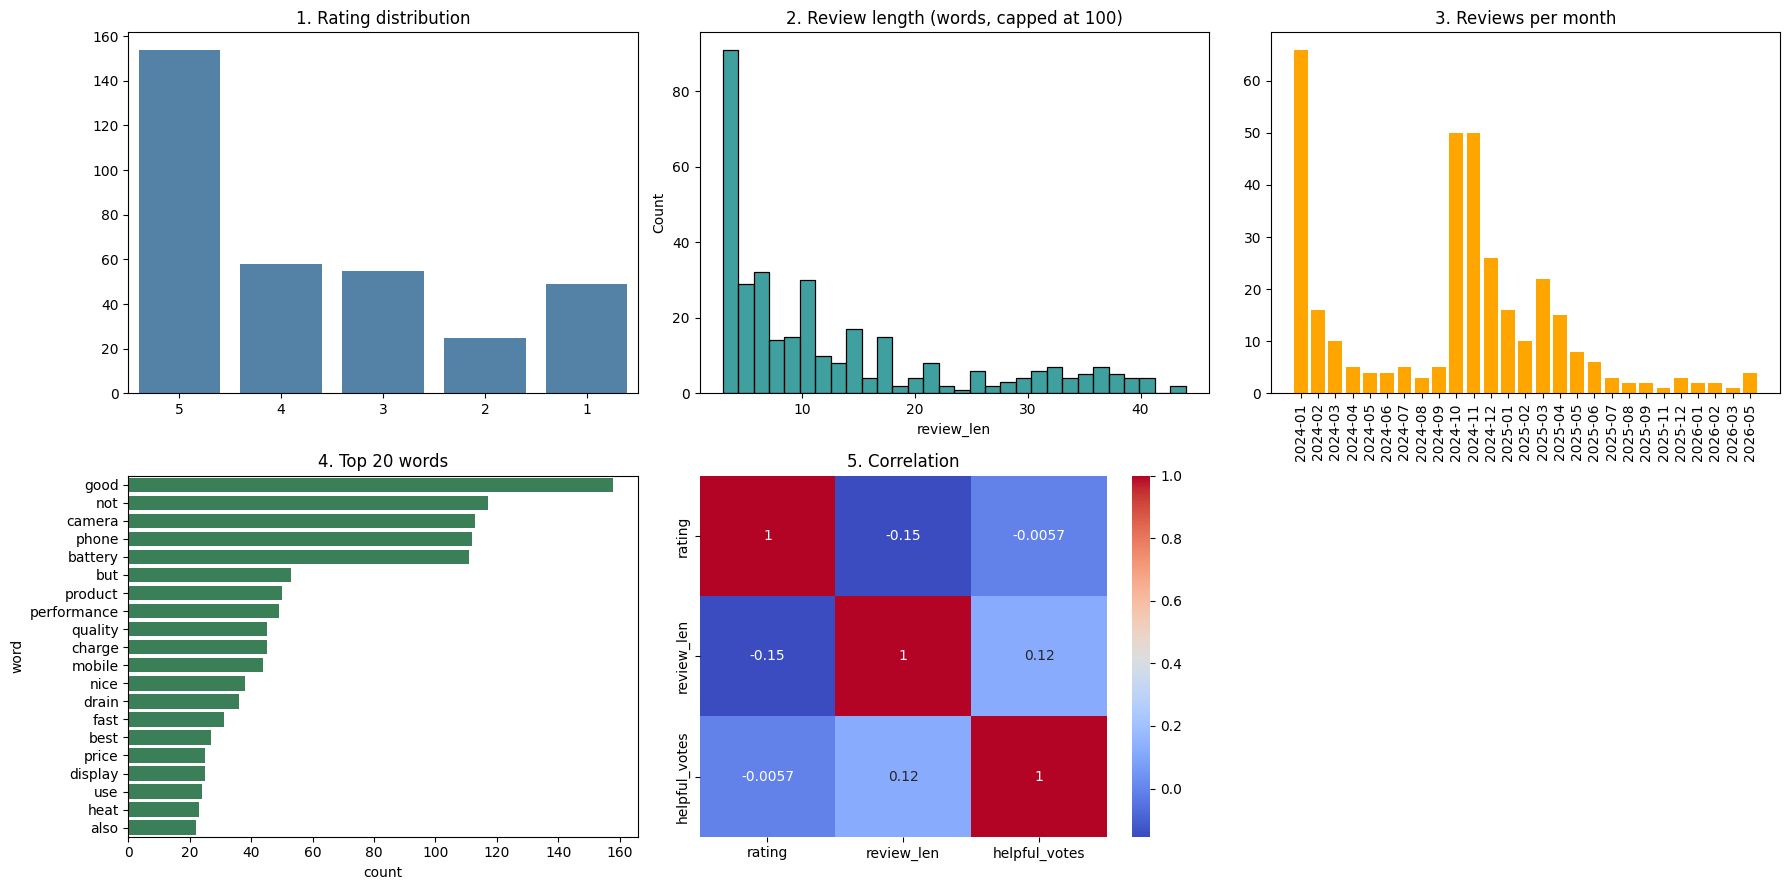

Battery mentioned in 29% of reviews, camera 29%, heating 9%
Rating vs length correlation: -0.15
Average rating: 3.71 | median review length: 9.0 words


In [15]:
import pandas as pd, matplotlib.pyplot as plt, seaborn as sns

PRODUCT = "redmi_note_13_pro_5g"      # change to any file name in data/processed
df = pd.read_csv(f"data/processed/{PRODUCT}.csv", parse_dates=["date"])
f = build_features(df)

fig, ax = plt.subplots(2, 3, figsize=(18, 9))

sns.barplot(x=list(f["rating_counts"].keys()), y=list(f["rating_counts"].values()),
            ax=ax[0, 0], color="steelblue")
ax[0, 0].set_title("1. Rating distribution")

sns.histplot(df["review_len"].clip(upper=100), bins=30, ax=ax[0, 1], color="teal")
ax[0, 1].set_title("2. Review length (words, capped at 100)")

m = pd.DataFrame(f["monthly"]).T
ax[0, 2].bar(m.index, m["count"], color="orange")
ax[0, 2].tick_params(axis="x", rotation=90)
ax[0, 2].set_title("3. Reviews per month")

w = pd.DataFrame(f["top_words"], columns=["word", "count"])
sns.barplot(data=w, y="word", x="count", ax=ax[1, 0], color="seagreen")
ax[1, 0].set_title("4. Top 20 words")

sns.heatmap(df[["rating", "review_len", "helpful_votes"]].corr(), annot=True,
            cmap="coolwarm", ax=ax[1, 1])
ax[1, 1].set_title("5. Correlation")

ax[1, 2].axis("off")
plt.tight_layout()
plt.show()

# Facts to help you write the insights
share = lambda kw: df["clean_text"].str.contains(kw).mean() * 100
print(f"Battery mentioned in {share('battery'):.0f}% of reviews, camera {share('camera'):.0f}%, "
      f"heating {share('heat'):.0f}%")
print("Rating vs length correlation:", round(df["rating"].corr(df["review_len"]), 2))
print("Average rating:", f["avg_rating"], "| median review length:", f["length_stats"]["median"], "words")

In [ ]:
Insights (Redmi Note 13 Pro 5G)
1. Ratings are moderately positive, with the average rating at 3.71. 5-star reviews are the most common, followed by 4-star reviews, but a considerable number of 1-star reviews also indicate customer dissatisfaction.
2. Most reviews are short (median 9 words), so each review carries limited detail. This is why analysing hundreds of reviews together helps identify overall customer opinions.
3. Camera (29%) and battery (29%) are the most discussed features, while heating appears in 9% of reviews. Words like "good", "camera", "phone", "battery" and "product" dominate the frequently mentioned words.
4. Longer reviews tend to have slightly lower ratings (correlation -0.15), while helpful votes show almost no relationship with ratings. Review activity varied over time, with noticeable peaks around late 2024 and early 2025.

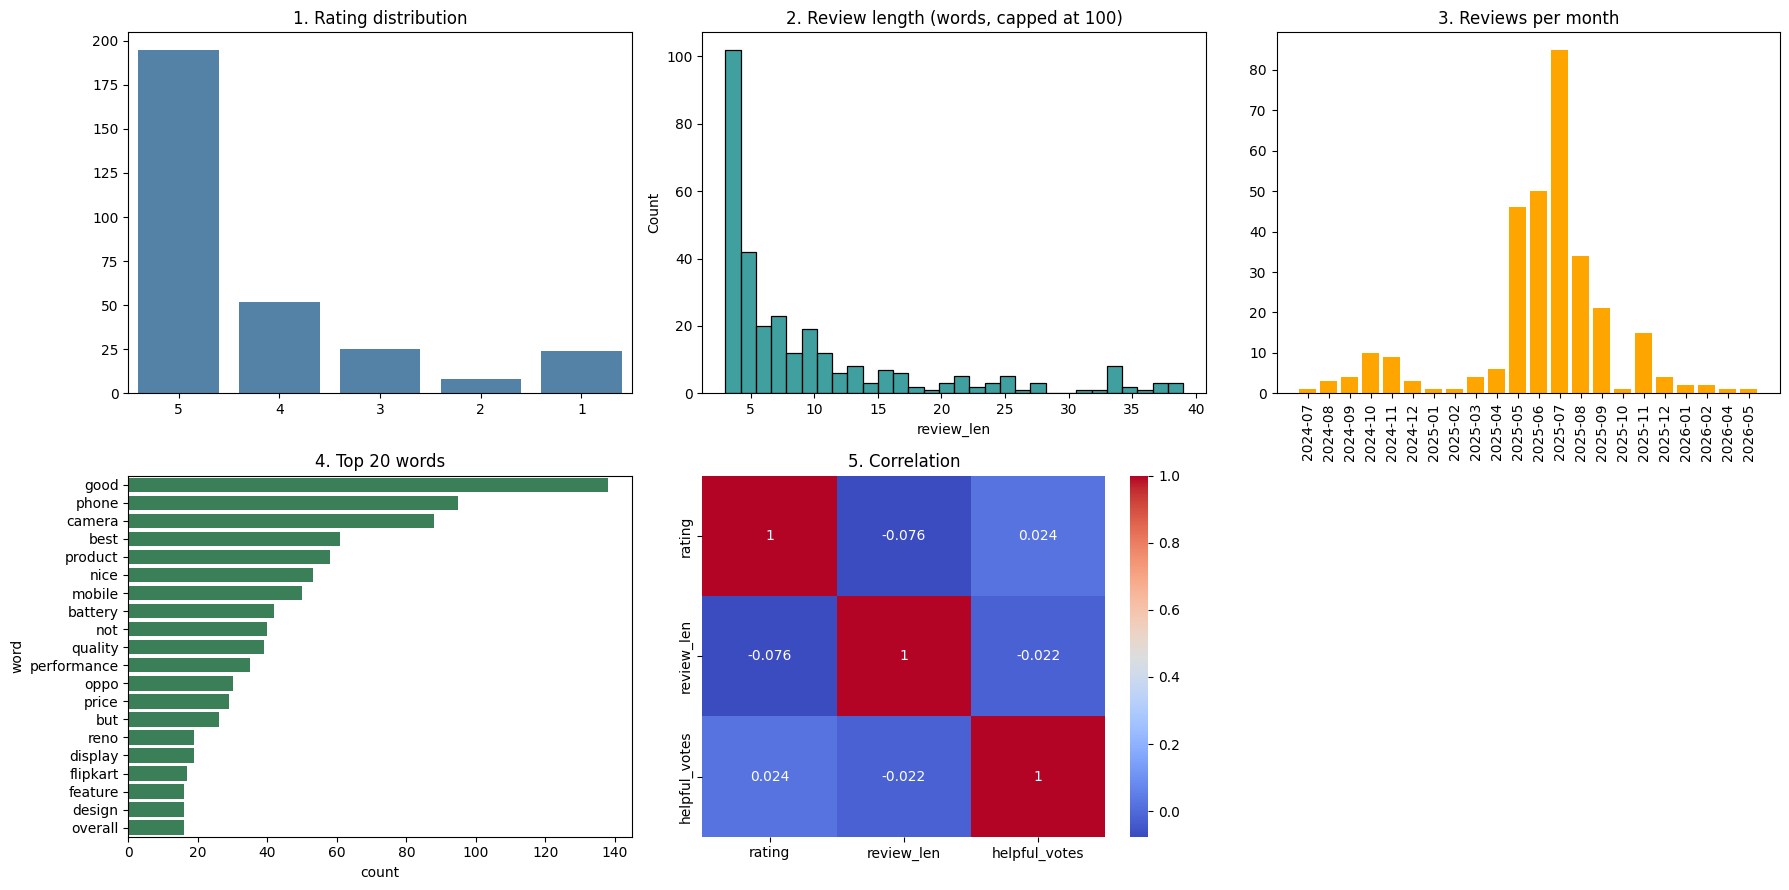

Battery mentioned in 14% of reviews, camera 28%, heating 2%
Rating vs length correlation: -0.08
Average rating: 4.27 | median review length: 6.0 words


In [16]:
import pandas as pd, matplotlib.pyplot as plt, seaborn as sns

PRODUCT = "oppo_reno_12_5g"      # change to any file name in data/processed
df = pd.read_csv(f"data/processed/{PRODUCT}.csv", parse_dates=["date"])
f = build_features(df)

fig, ax = plt.subplots(2, 3, figsize=(18, 9))

sns.barplot(x=list(f["rating_counts"].keys()), y=list(f["rating_counts"].values()),
            ax=ax[0, 0], color="steelblue")
ax[0, 0].set_title("1. Rating distribution")

sns.histplot(df["review_len"].clip(upper=100), bins=30, ax=ax[0, 1], color="teal")
ax[0, 1].set_title("2. Review length (words, capped at 100)")

m = pd.DataFrame(f["monthly"]).T
ax[0, 2].bar(m.index, m["count"], color="orange")
ax[0, 2].tick_params(axis="x", rotation=90)
ax[0, 2].set_title("3. Reviews per month")

w = pd.DataFrame(f["top_words"], columns=["word", "count"])
sns.barplot(data=w, y="word", x="count", ax=ax[1, 0], color="seagreen")
ax[1, 0].set_title("4. Top 20 words")

sns.heatmap(df[["rating", "review_len", "helpful_votes"]].corr(), annot=True,
            cmap="coolwarm", ax=ax[1, 1])
ax[1, 1].set_title("5. Correlation")

ax[1, 2].axis("off")
plt.tight_layout()
plt.show()

# Facts to help you write the insights
share = lambda kw: df["clean_text"].str.contains(kw).mean() * 100
print(f"Battery mentioned in {share('battery'):.0f}% of reviews, camera {share('camera'):.0f}%, "
      f"heating {share('heat'):.0f}%")
print("Rating vs length correlation:", round(df["rating"].corr(df["review_len"]), 2))
print("Average rating:", f["avg_rating"], "| median review length:", f["length_stats"]["median"], "words")

In [ ]:
Insights (OPPO Reno 12 5G)
1. Ratings are highly positive, with an average rating of 4.27. Most reviews give 5 stars, followed by 4-star ratings, indicating generally positive customer experiences.
2. Most reviews are short (median 6 words), so each review carries limited detail. Analysing hundreds of reviews together helps identify overall customer opinions and common patterns.
3. Camera (28%) and battery (14%) are frequently discussed features, while heating appears in only 2% of reviews. Words like "good", "phone", "camera", "best" and "product" dominate the top words.
4. Longer reviews have a very weak negative correlation with ratings (-0.08), while helpful votes show almost no relationship with ratings (0.024). Review activity peaked around mid-2025, particularly in July.

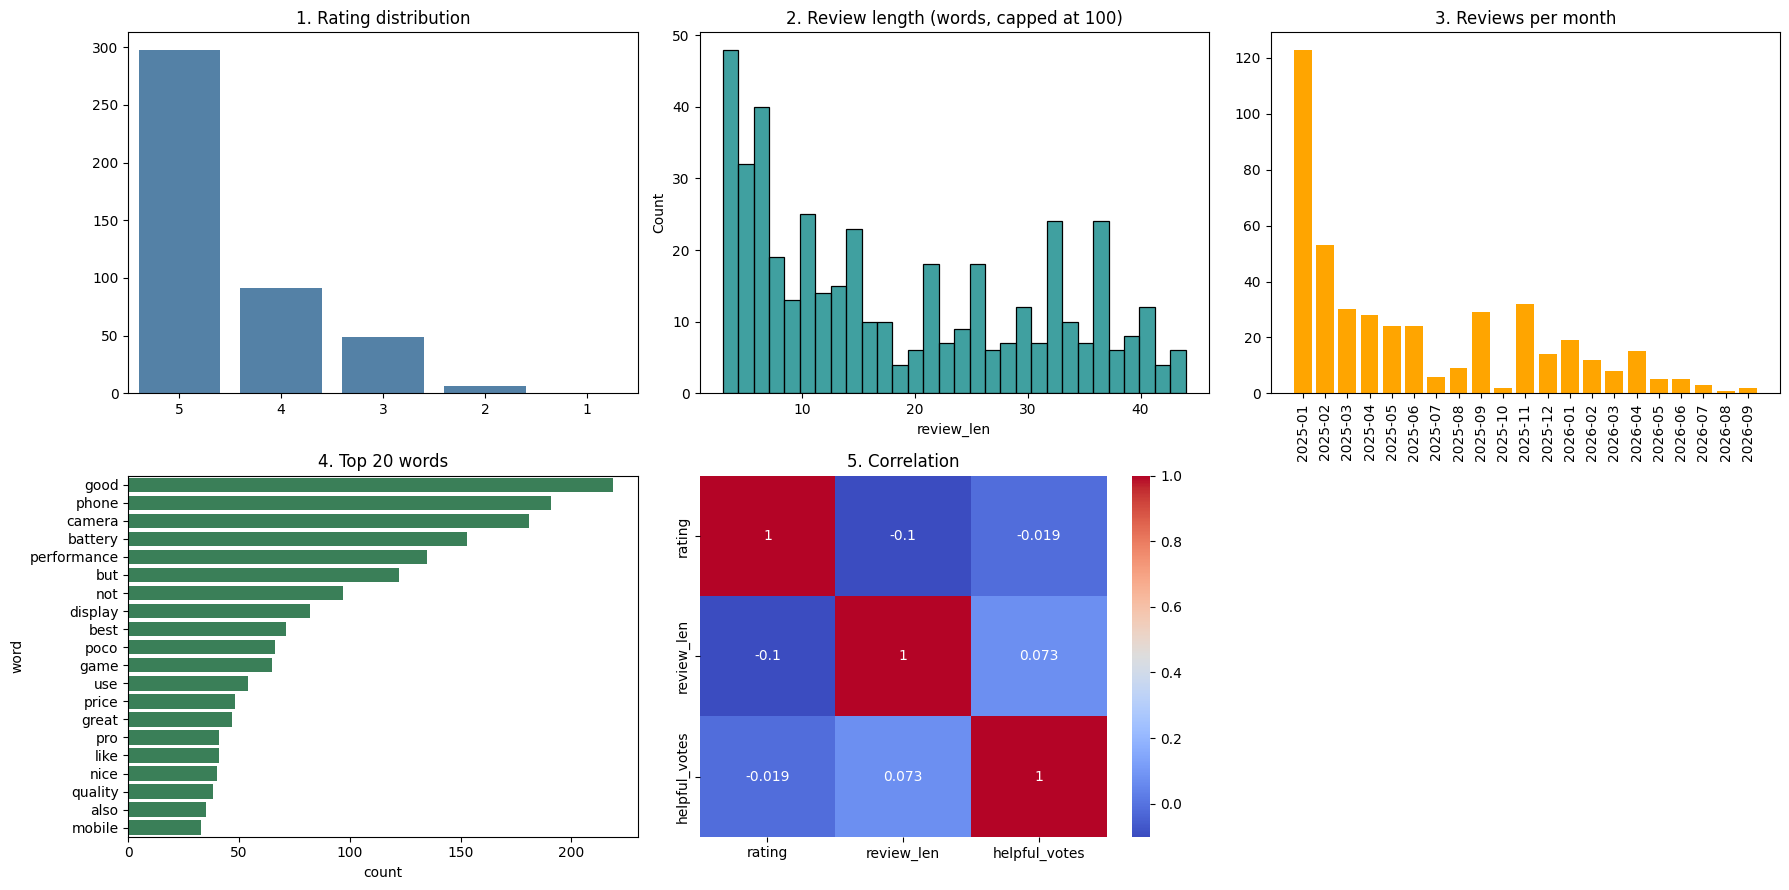

Battery mentioned in 30% of reviews, camera 35%, heating 6%
Rating vs length correlation: -0.1
Average rating: 4.53 | median review length: 15.0 words


In [17]:
import pandas as pd, matplotlib.pyplot as plt, seaborn as sns

PRODUCT = "poco_x6_pro_5g"      # change to any file name in data/processed
df = pd.read_csv(f"data/processed/{PRODUCT}.csv", parse_dates=["date"])
f = build_features(df)

fig, ax = plt.subplots(2, 3, figsize=(18, 9))

sns.barplot(x=list(f["rating_counts"].keys()), y=list(f["rating_counts"].values()),
            ax=ax[0, 0], color="steelblue")
ax[0, 0].set_title("1. Rating distribution")

sns.histplot(df["review_len"].clip(upper=100), bins=30, ax=ax[0, 1], color="teal")
ax[0, 1].set_title("2. Review length (words, capped at 100)")

m = pd.DataFrame(f["monthly"]).T
ax[0, 2].bar(m.index, m["count"], color="orange")
ax[0, 2].tick_params(axis="x", rotation=90)
ax[0, 2].set_title("3. Reviews per month")

w = pd.DataFrame(f["top_words"], columns=["word", "count"])
sns.barplot(data=w, y="word", x="count", ax=ax[1, 0], color="seagreen")
ax[1, 0].set_title("4. Top 20 words")

sns.heatmap(df[["rating", "review_len", "helpful_votes"]].corr(), annot=True,
            cmap="coolwarm", ax=ax[1, 1])
ax[1, 1].set_title("5. Correlation")

ax[1, 2].axis("off")
plt.tight_layout()
plt.show()

# Facts to help you write the insights
share = lambda kw: df["clean_text"].str.contains(kw).mean() * 100
print(f"Battery mentioned in {share('battery'):.0f}% of reviews, camera {share('camera'):.0f}%, "
      f"heating {share('heat'):.0f}%")
print("Rating vs length correlation:", round(df["rating"].corr(df["review_len"]), 2))
print("Average rating:", f["avg_rating"], "| median review length:", f["length_stats"]["median"], "words")

In [ ]:
Insights (POCO X6 Pro 5G)
1. Ratings are highly positive, with an average rating of 4.53. Most reviews give 5 stars, followed by 4-star ratings, indicating strong overall customer satisfaction.
2. Reviews are moderately detailed, with a median length of 15 words. This provides more customer feedback per review compared to products with shorter reviews.
3. Battery (30%) and camera (35%) are the most discussed features, while heating appears in 6% of reviews. Words like "good", "phone", "camera", "battery" and "performance" dominate the top words.
4. Longer reviews tend to have slightly lower ratings (correlation -0.10), while helpful votes show almost no relationship with ratings (-0.019). Review activity peaked in January 2025, with another noticeable increase around October and November 2025.

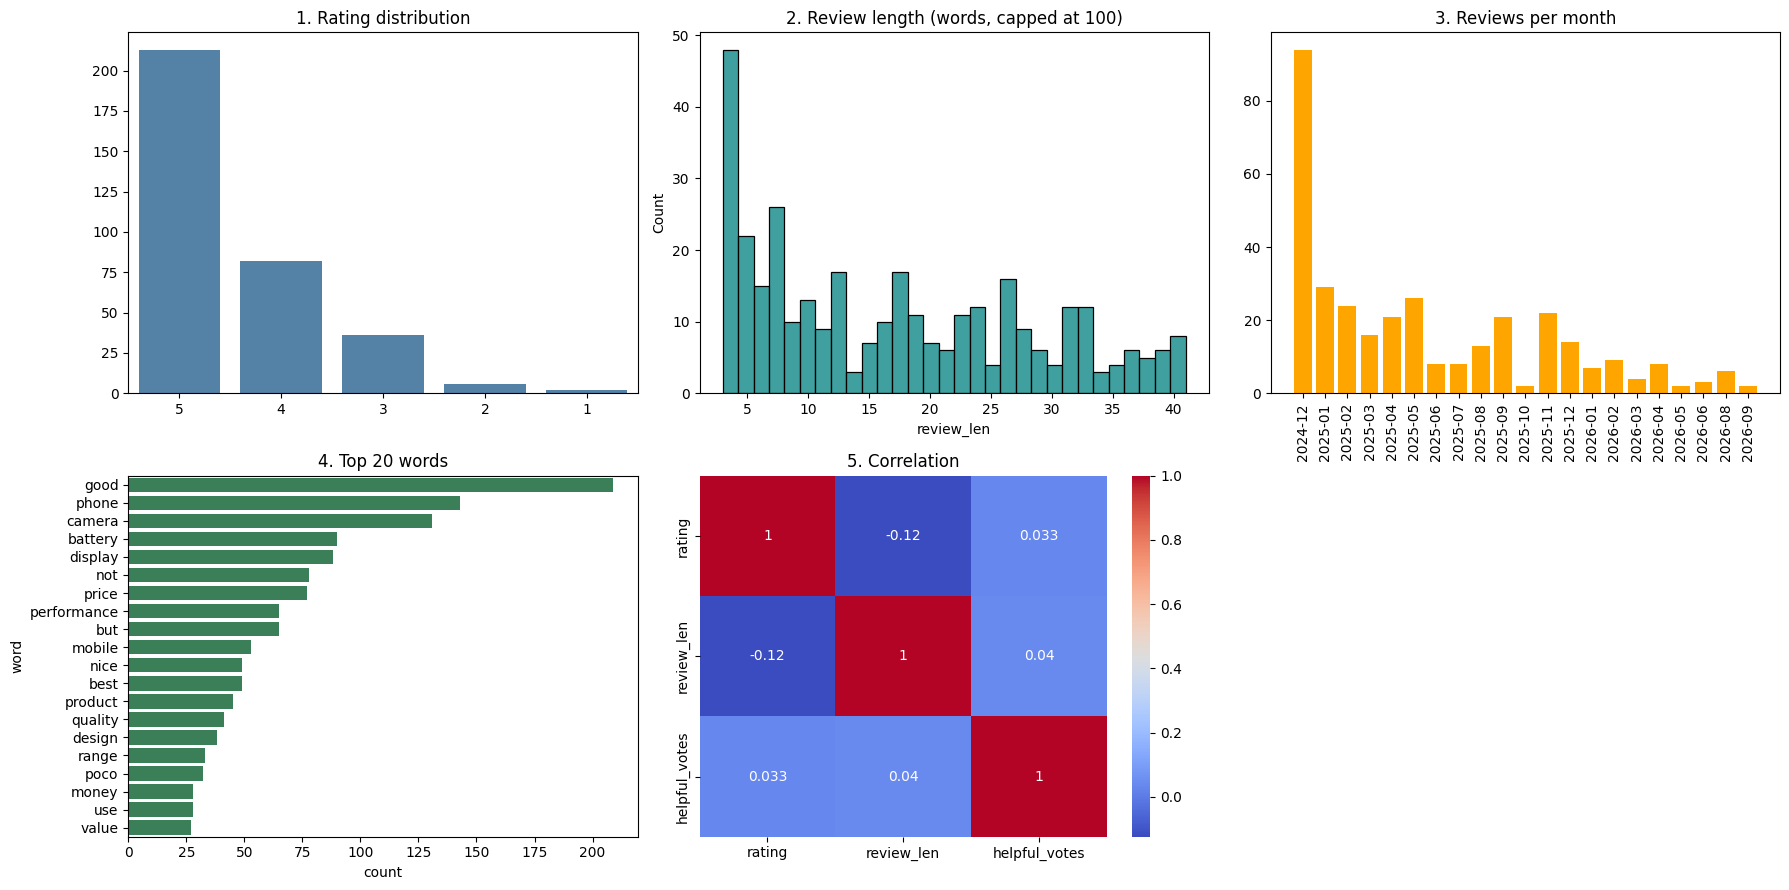

Battery mentioned in 24% of reviews, camera 34%, heating 3%
Rating vs length correlation: -0.12
Average rating: 4.47 | median review length: 15.0 words


In [18]:
import pandas as pd, matplotlib.pyplot as plt, seaborn as sns

PRODUCT = "poco_m6_pro_5g"      # change to any file name in data/processed
df = pd.read_csv(f"data/processed/{PRODUCT}.csv", parse_dates=["date"])
f = build_features(df)

fig, ax = plt.subplots(2, 3, figsize=(18, 9))

sns.barplot(x=list(f["rating_counts"].keys()), y=list(f["rating_counts"].values()),
            ax=ax[0, 0], color="steelblue")
ax[0, 0].set_title("1. Rating distribution")

sns.histplot(df["review_len"].clip(upper=100), bins=30, ax=ax[0, 1], color="teal")
ax[0, 1].set_title("2. Review length (words, capped at 100)")

m = pd.DataFrame(f["monthly"]).T
ax[0, 2].bar(m.index, m["count"], color="orange")
ax[0, 2].tick_params(axis="x", rotation=90)
ax[0, 2].set_title("3. Reviews per month")

w = pd.DataFrame(f["top_words"], columns=["word", "count"])
sns.barplot(data=w, y="word", x="count", ax=ax[1, 0], color="seagreen")
ax[1, 0].set_title("4. Top 20 words")

sns.heatmap(df[["rating", "review_len", "helpful_votes"]].corr(), annot=True,
            cmap="coolwarm", ax=ax[1, 1])
ax[1, 1].set_title("5. Correlation")

ax[1, 2].axis("off")
plt.tight_layout()
plt.show()

# Facts to help you write the insights
share = lambda kw: df["clean_text"].str.contains(kw).mean() * 100
print(f"Battery mentioned in {share('battery'):.0f}% of reviews, camera {share('camera'):.0f}%, "
      f"heating {share('heat'):.0f}%")
print("Rating vs length correlation:", round(df["rating"].corr(df["review_len"]), 2))
print("Average rating:", f["avg_rating"], "| median review length:", f["length_stats"]["median"], "words")

In [ ]:
Insights (POCO M6 Pro 5G)
1. Ratings are highly positive, with an average rating of 4.47. Most reviews give 5 stars, followed by 4-star ratings, indicating generally positive customer experiences.
2. Reviews are moderately detailed, with a median length of 15 words. This provides a reasonable amount of customer feedback per review for identifying common opinions and trends.
3. Camera (34%) and battery (24%) are the most discussed features, while heating appears in only 3% of reviews. Words like "good", "phone", "camera", "battery" and "display" dominate the top words.
4. Longer reviews tend to have slightly lower ratings (correlation -0.12), while helpful votes show almost no relationship with ratings (0.033). Review activity peaked in December 2024, with smaller increases during May and October 2025.

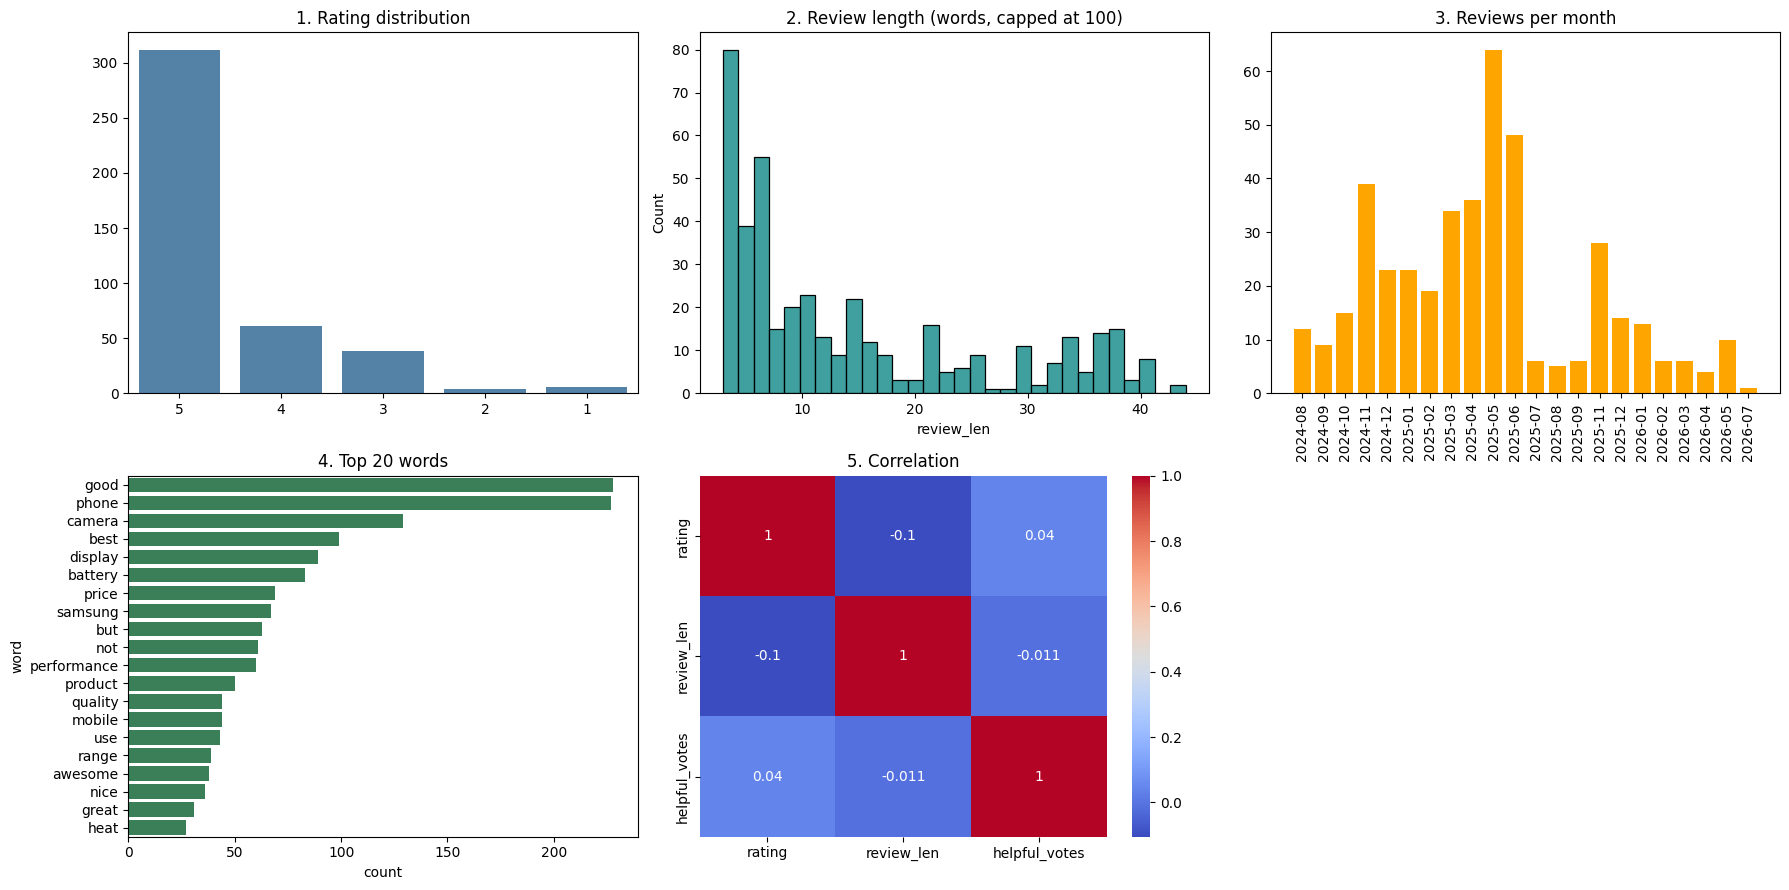

Battery mentioned in 18% of reviews, camera 28%, heating 6%
Rating vs length correlation: -0.1
Average rating: 4.59 | median review length: 10.0 words


In [19]:
import pandas as pd, matplotlib.pyplot as plt, seaborn as sns

PRODUCT = "samsung_galaxy_m35_5g"      # change to any file name in data/processed
df = pd.read_csv(f"data/processed/{PRODUCT}.csv", parse_dates=["date"])
f = build_features(df)

fig, ax = plt.subplots(2, 3, figsize=(18, 9))

sns.barplot(x=list(f["rating_counts"].keys()), y=list(f["rating_counts"].values()),
            ax=ax[0, 0], color="steelblue")
ax[0, 0].set_title("1. Rating distribution")

sns.histplot(df["review_len"].clip(upper=100), bins=30, ax=ax[0, 1], color="teal")
ax[0, 1].set_title("2. Review length (words, capped at 100)")

m = pd.DataFrame(f["monthly"]).T
ax[0, 2].bar(m.index, m["count"], color="orange")
ax[0, 2].tick_params(axis="x", rotation=90)
ax[0, 2].set_title("3. Reviews per month")

w = pd.DataFrame(f["top_words"], columns=["word", "count"])
sns.barplot(data=w, y="word", x="count", ax=ax[1, 0], color="seagreen")
ax[1, 0].set_title("4. Top 20 words")

sns.heatmap(df[["rating", "review_len", "helpful_votes"]].corr(), annot=True,
            cmap="coolwarm", ax=ax[1, 1])
ax[1, 1].set_title("5. Correlation")

ax[1, 2].axis("off")
plt.tight_layout()
plt.show()

# Facts to help you write the insights
share = lambda kw: df["clean_text"].str.contains(kw).mean() * 100
print(f"Battery mentioned in {share('battery'):.0f}% of reviews, camera {share('camera'):.0f}%, "
      f"heating {share('heat'):.0f}%")
print("Rating vs length correlation:", round(df["rating"].corr(df["review_len"]), 2))
print("Average rating:", f["avg_rating"], "| median review length:", f["length_stats"]["median"], "words")

In [ ]:
Insights (Samsung Galaxy M35)

1. Ratings are heavily positive: about 310 of the ~420 reviews are 5-star, and
   the average rating is 4.59. Very few reviews give 1 or 2 stars.
2. Most reviews are short (median 10 words), so the text carries limited detail
   per review. This is why we analyse hundreds of reviews together.
3. Camera (28%) and battery (18%) are the most discussed features, while
   heating appears in only 6% of reviews. Words like "good", "phone", "camera",
   "display" and "battery" dominate the top words.
4. Longer reviews tend to have slightly lower ratings (correlation -0.1), and
   helpful votes show almost no link with rating. Review activity peaked around
   mid-2025.

In [20]:
"""
analyze.py - Tasks 5, 6, 7: sentiment (VADER), aspect scores, trust score.

Main function:
    analyze_reviews(df) -> (df_with_new_columns, stats_dict)

df needs: rating, text, lemmas   (lemmas can be a list or a 'word word' string)

New df columns : vader, sentiment, flag_duplicate, flag_short5, flag_mismatch, flagged
stats_dict keys: sentiment_split, aspect_scores, aspect_mentions, trust_score,
                 flagged_count, adjusted_avg_rating, pos_words, neg_words

Run:  python analyze.py     (analyzes every file in data/processed/)
"""
import glob
import os
import re
from collections import Counter

import nltk
import pandas as pd
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from nltk.tokenize import sent_tokenize

PROC_DIR = "data/processed"

# ---------------------------------------------------------------
# SETTINGS (edit here)
# ---------------------------------------------------------------
# Keywords for each aspect. Edit freely.
ASPECTS = {
    "battery": ["battery", "charge", "charging", "backup", "mah"],
    "camera": ["camera", "photo", "picture", "video", "selfie"],
    "display": ["display", "screen", "amoled", "brightness"],
    "performance": ["performance", "speed", "lag", "processor", "gaming", "smooth"],
    "heating": ["heat", "heating", "overheat", "hot", "warm"],
    "price": ["price", "value", "money", "budget"],
}
MIN_MENTIONS = 5          # skip an aspect with fewer sentences than this
POS_T, NEG_T = 0.05, -0.05  # VADER thresholds
# Words left out of the two word clouds (they appear in every review and say nothing)
CLOUD_SKIP = {"not", "no", "but", "never", "nor", "phone", "mobile", "product", "get", "use", "one"}


def ensure_nltk():
    needed = {"sentiment/vader_lexicon.zip": "vader_lexicon",
              "tokenizers/punkt": "punkt",
              "tokenizers/punkt_tab": "punkt_tab"}
    for path, name in needed.items():
        try:
            nltk.data.find(path)
        except LookupError:
            nltk.download(name, quiet=True)


ensure_nltk()


def as_list(x):
    if isinstance(x, list):
        return x
    if pd.isna(x):
        return []
    return str(x).split()


# ---------------------------------------------------------------
# TASK 5: SENTIMENT
# ---------------------------------------------------------------
def add_sentiment(df, sia):
    """VADER runs on the ORIGINAL text (it reads capitals and punctuation)."""
    df["vader"] = df["text"].astype(str).apply(lambda t: sia.polarity_scores(t)["compound"])
    df["sentiment"] = df["vader"].apply(
        lambda c: "positive" if c >= POS_T else ("negative" if c <= NEG_T else "neutral"))
    return df


def sentiment_split(df):
    n = len(df)
    pos = round(100 * (df["sentiment"] == "positive").sum() / n)
    neg = round(100 * (df["sentiment"] == "negative").sum() / n)
    neu = max(0, 100 - pos - neg)                  # always adds up to 100
    return {"positive": int(pos), "neutral": int(neu), "negative": int(neg)}


def word_frequencies(df, label, top=50):
    c = Counter()
    for lemmas in df.loc[df["sentiment"] == label, "lemmas"]:
        c.update(w for w in as_list(lemmas) if w not in CLOUD_SKIP)
    return {w: int(n) for w, n in c.most_common(top)}


# ---------------------------------------------------------------
# TASK 6: ASPECTS
# ---------------------------------------------------------------
def _aspect_patterns():
    # a keyword also matches common endings: heat -> heats/heated, photo -> photos, charge -> charger
    return {a: re.compile(r"\b(?:" + "|".join(map(re.escape, kws)) + r")(?:s|es|ed|d|r|rs|ing|er|ers)?\b")
            for a, kws in ASPECTS.items()}


def aspect_analysis(df, sia):
    patterns = _aspect_patterns()
    scores = {a: [] for a in ASPECTS}
    for text in df["text"].astype(str):
        for sent in sent_tokenize(text):
            low = sent.lower()
            hits = [a for a, p in patterns.items() if p.search(low)]
            if hits:
                c = sia.polarity_scores(sent)["compound"]
                for a in hits:
                    scores[a].append(c)

    aspect_scores, aspect_mentions = {}, {}
    for a, vals in scores.items():
        if len(vals) < MIN_MENTIONS:
            continue
        aspect_scores[a] = int(round(100 * sum(v >= POS_T for v in vals) / len(vals)))
        aspect_mentions[a] = len(vals)
    return aspect_scores, aspect_mentions


def show_aspect_sentences(df, aspect, n=10):
    """Print n sentences for one aspect with their VADER score, so you can check them by eye."""
    sia = SentimentIntensityAnalyzer()
    pat = _aspect_patterns()[aspect]
    shown = 0
    for text in df["text"].astype(str):
        for sent in sent_tokenize(text):
            if pat.search(sent.lower()):
                c = sia.polarity_scores(sent)["compound"]
                print(f"{c:+.2f}  {sent.strip()}")
                shown += 1
                if shown >= n:
                    return


# ---------------------------------------------------------------
# TASK 7: TRUST SCORE
# ---------------------------------------------------------------
def add_trust_flags(df):
    # Flag 1: identical text (ignoring case and punctuation)
    norm = (df["text"].astype(str).str.lower()
            .str.replace(r"[^\w\s]", "", regex=True).str.strip())
    df["flag_duplicate"] = norm.duplicated(keep=False)

    # Flag 2: 5-star review with fewer than 6 words ("nice product")
    words = df["text"].astype(str).str.split().str.len()
    df["flag_short5"] = (df["rating"] == 5) & (words < 6)

    # Flag 3: stars and text disagree
    df["flag_mismatch"] = (((df["rating"] >= 4) & (df["vader"] <= -0.3)) |
                           ((df["rating"] <= 2) & (df["vader"] >= 0.5)))

    df["flagged"] = df["flag_duplicate"] | df["flag_short5"] | df["flag_mismatch"]
    return df


def trust_stats(df):
    total = len(df)
    flagged = int(df["flagged"].sum())
    trust = int(round(100 * (1 - flagged / total)))
    kept = df.loc[~df["flagged"], "rating"]
    adjusted = round(float(kept.mean()), 2) if len(kept) else round(float(df["rating"].mean()), 2)
    return trust, flagged, adjusted


# ---------------------------------------------------------------
# MAIN FUNCTION
# ---------------------------------------------------------------
def analyze_reviews(df):
    df = df.copy().reset_index(drop=True)
    df["rating"] = pd.to_numeric(df["rating"], errors="coerce")
    sia = SentimentIntensityAnalyzer()

    df = add_sentiment(df, sia)
    aspect_scores, aspect_mentions = aspect_analysis(df, sia)
    df = add_trust_flags(df)
    trust, flagged, adjusted = trust_stats(df)

    stats = {
        "sentiment_split": sentiment_split(df),
        "aspect_scores": aspect_scores,
        "aspect_mentions": aspect_mentions,
        "trust_score": trust,
        "flagged_count": flagged,
        "adjusted_avg_rating": adjusted,
        "pos_words": word_frequencies(df, "positive"),
        "neg_words": word_frequencies(df, "negative"),
    }
    return df, stats


if __name__ == "__main__":
    files = [f for f in sorted(glob.glob(os.path.join(PROC_DIR, "*.csv")))
             if not os.path.basename(f).startswith("_")]
    if not files:
        print(f"No CSV files in {PROC_DIR}. Run preprocess.py first.")
        raise SystemExit

    table = []
    first = None
    for f in files:
        df = pd.read_csv(f, parse_dates=["date"])
        out, s = analyze_reviews(df)
        name = out["product_name"].iloc[0] if "product_name" in out else os.path.basename(f)

        star = out["rating"].apply(lambda r: "positive" if r >= 4 else ("neutral" if r == 3 else "negative"))
        star_split = (star.value_counts(normalize=True) * 100).round().astype(int).to_dict()

        print("\n" + "=" * 70)
        print(name, f"({len(out)} reviews)")
        print("VADER sentiment split :", s["sentiment_split"])
        print("Star-rating split     :", star_split, " <- should be roughly similar")
        print("Aspect scores         :", s["aspect_scores"])
        print("Aspect mentions       :", s["aspect_mentions"])
        print(f"Trust score {s['trust_score']} ({s['flagged_count']} suspicious reviews) | "
              f"average rating {out['rating'].mean():.2f} -> adjusted {s['adjusted_avg_rating']}")
        print("Flags: duplicate", int(out["flag_duplicate"].sum()),
              "| short 5-star", int(out["flag_short5"].sum()),
              "| rating-text mismatch", int(out["flag_mismatch"].sum()))
        table.append({"product": name, "reviews": len(out),
                      "positive%": s["sentiment_split"]["positive"],
                      "trust": s["trust_score"], "avg_rating": round(out["rating"].mean(), 2),
                      "adjusted_rating": s["adjusted_avg_rating"]})
        if first is None:
            first = out

    print("\n" + "=" * 70)
    print("Summary table (for your report):")
    print(pd.DataFrame(table).to_string(index=False))

    # Checks the plan asks for, on the first product
    print("\n5 suspicious reviews (check they look suspicious):")
    print(first.loc[first["flagged"], ["rating", "text", "vader"]].head(5).to_string())
    print("\n10 battery sentences with their VADER score (check they match):")
    show_aspect_sentences(first, "battery", 10)


OPPO Reno 12 5G (Matte Brown, 256 GB) (304 reviews)
VADER sentiment split : {'positive': 77, 'neutral': 8, 'negative': 15}
Star-rating split     : {'positive': 81, 'negative': 11, 'neutral': 8}  <- should be roughly similar
Aspect scores         : {'battery': 65, 'camera': 80, 'display': 68, 'performance': 66, 'heating': 0, 'price': 90}
Aspect mentions       : {'battery': 46, 'camera': 91, 'display': 22, 'performance': 47, 'heating': 6, 'price': 50}
Trust score 64 (110 suspicious reviews) | average rating 4.27 -> adjusted 3.93
Flags: duplicate 22 | short 5-star 98 | rating-text mismatch 7

POCO M7 Pro 5G (Lavender Frost, 128 GB) (339 reviews)
VADER sentiment split : {'positive': 83, 'neutral': 7, 'negative': 10}
Star-rating split     : {'positive': 87, 'neutral': 11, 'negative': 2}  <- should be roughly similar
Aspect scores         : {'battery': 67, 'camera': 77, 'display': 86, 'performance': 71, 'heating': 60, 'price': 85}
Aspect mentions       : {'battery': 97, 'camera': 130, 'disp